In [7]:
import numpy as np
import matplotlib.pyplot as plt
import csv

from skyfield.api import load, Loader, wgs84
from skyfield.data import hipparcos, stellarium

from astropy.coordinates import SkyCoord
import astropy.units as u
from geopy.geocoders import Nominatim

from astropy.coordinates import EarthLocation, AltAz
from astropy.time import Time

from datetime import timezone
from zoneinfo import ZoneInfo

In [8]:
def find_address_from_coords(latin,lonin):
    # Initialize the geocoder (always use a unique user_agent)
    geolocator = Nominatim(user_agent="my_town_finder_app")
    
    address_info = geolocator.reverse(f"{latin}, {lonin}")
    address_dict = address_info.raw.get('address', {})
    
    # Print the full dictionary to see everything OpenStreetMap knows about this spot:
    #pprint.pprint(address_dict)
    
    # Safely grab the most specific local name available
    suburb = address_dict.get('suburb')         # Might return 'Riedbahn'
    town = address_dict.get('town')             # Might return 'Weiterstadt'
    city = address_dict.get('city')             # Returns 'Darmstadt'
    
    # Elegant fallback logic:
    display_name = suburb or town or city
    #print(f"Specific Location: {display_name}")

    return display_name

In [9]:
#-----------------------------------------
#     OBSERVER + TIME (Skyfield ONLY)
#-----------------------------------------

ts = load.timescale()
t = ts.utc(2026, 6, 20, 22, 0, 0)

obs_time = Time("2026-06-21 22:00:00")

eph = load("data/de421.bsp")
earth = eph["earth"]


latin=49.8866755
lonin=8.6095692

location_of_observation = find_address_from_coords(latin,lonin)    

location = wgs84.latlon(latin, lonin, elevation_m=110)

observer = earth + location

#-----------------------------------------
#     LOAD DATA
#-----------------------------------------
load_data = Loader('data')

with load_data.open(hipparcos.URL) as f:
    stars = hipparcos.load_dataframe(f)
    
#with load.open(hipparcos.URL) as f:
#    stars = hipparcos.load_dataframe(f)

with open("data/constellationship.fab", "rb") as f:
    constellations = stellarium.parse_constellations(f)

Could not resolve None: quote_from_bytes() expected bytes
2026-06-22 00:00


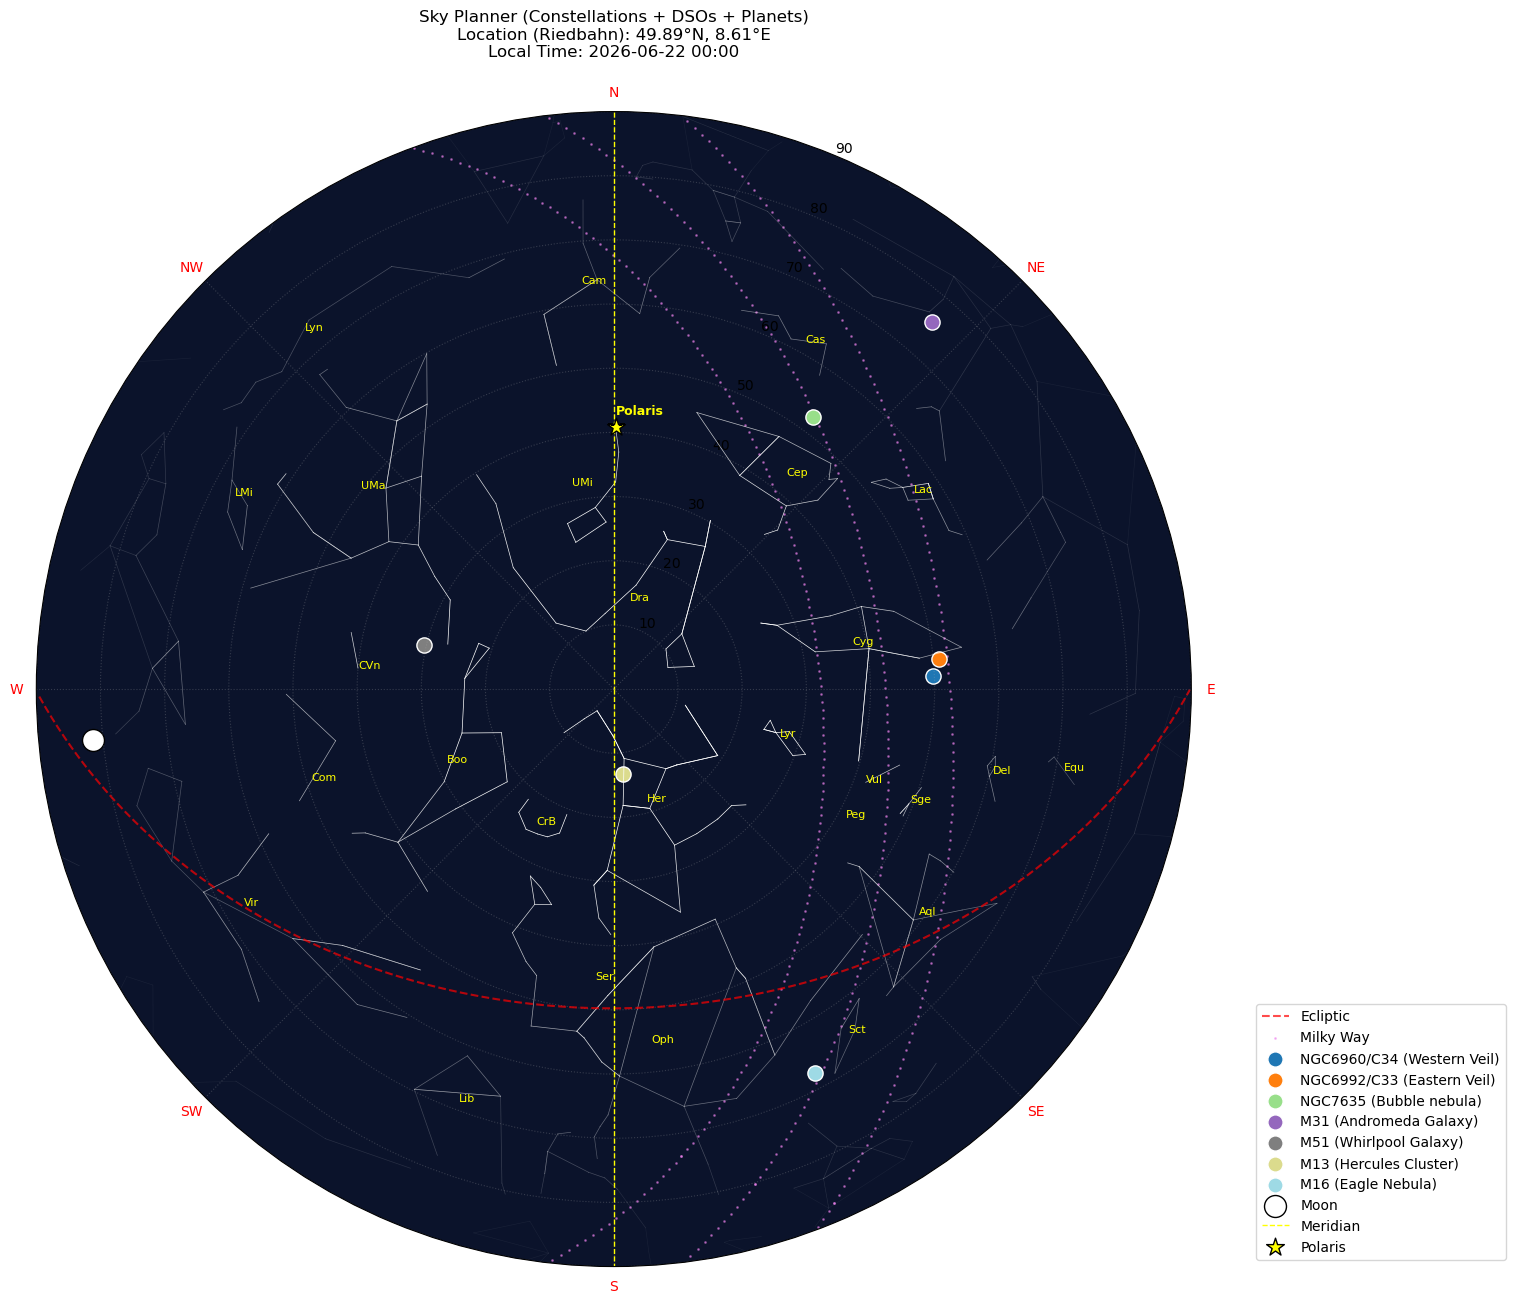

In [10]:
#-----------------------------------------
#     PLOT SETUP
#-----------------------------------------
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(111, polar=True)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_ylim(0, 90)

ax.set_facecolor("#0B132B")
ax.grid(alpha=0.25, linestyle=":")

#-----------------------------------------
#  Convert Skyfield → RA/Dec → Astropy → AltAz.
#-----------------------------------------
    
astro_location = EarthLocation(lat=49.7*u.deg, lon=8.8*u.deg, height=200*u.m)
astro_time = obs_time
altaz_frame = AltAz(obstime=astro_time, location=astro_location)


def to_altaz(ra_deg, dec_deg):
    c = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)
    return c.transform_to(altaz_frame)

#-----------------------------------------
#  CONSTELLATIONS
#-----------------------------------------
for abbr, segs in constellations:

    for s1, s2 in segs:

        try:
            r1 = stars.loc[s1]
            r2 = stars.loc[s2]
        except:
            continue

        a1 = to_altaz(r1["ra_degrees"], r1["dec_degrees"])
        a2 = to_altaz(r2["ra_degrees"], r2["dec_degrees"])

        if a1.alt.deg <= 0 and a2.alt.deg <= 0:
            continue

        fade = np.clip(min(a1.alt.deg, a2.alt.deg)/60, 0.05, 1)

        ax.plot(
            [a1.az.radian, a2.az.radian],
            [90-a1.alt.deg, 90-a2.alt.deg],
            color="white",
            alpha=fade,
            linewidth=0.5
        )

#-----------------------------------------
#      CONSTELLATION LABELS
#-----------------------------------------
for abbr, segs in constellations:

    ras = []
    decs = []

    for s1, s2 in segs:
        try:
            ras.append(stars.loc[s1]["ra_degrees"])
            decs.append(stars.loc[s1]["dec_degrees"])
        except:
            continue

    if not ras:
        continue

    c = SkyCoord(np.mean(ras)*u.deg, np.mean(decs)*u.deg)
    a = c.transform_to(altaz_frame)

    if a.alt.deg > 15:
        ax.text(
            a.az.radian,
            90-a.alt.deg,
            abbr,
            color="yellow",
            fontsize=8
        )

#-----------------------------------------
# ECLIPTIC
#-----------------------------------------

ecl_az, ecl_r = [], []

for lon in np.linspace(0, 360, 500):

    c = SkyCoord(lon*u.deg, 0*u.deg, frame="icrs")
    a = c.transform_to(altaz_frame)

    if a.alt.deg > 0:
        ecl_az.append(a.az.radian)
        ecl_r.append(90-a.alt.deg)

ax.plot(ecl_az, ecl_r, "r--", alpha=0.7, label='Ecliptic')


#-----------------------------------------
#    MILKY WAY (simple band)
#-----------------------------------------
mw_az, mw_r = [], []

for l in np.linspace(0, 360, 300):
    for b in [-10, 0, 10]:

        c = SkyCoord(l*u.deg, b*u.deg, frame="galactic").icrs
        a = c.transform_to(altaz_frame)

        if a.alt.deg > 0:
            mw_az.append(a.az.radian)
            mw_r.append(90-a.alt.deg)

ax.scatter(mw_az, mw_r, s=1, alpha=0.5, color="violet",label='Milky Way')


#-----------------------------------------
# DSOs (simple placeholder)
#-----------------------------------------

dsos = []

with open("data/targets.txt", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)

    for row in reader:
        try:
            coord = SkyCoord.from_name(row["id"])

            dsos.append({
                "name": row["name"],
                "coord": coord
            })

            #print(f"Resolved {row['id']}")

        except Exception as e:
            print(f"Could not resolve {row['id']}: {e}")
            
colors = plt.cm.tab20(np.linspace(0, 1, len(dsos)))
for dso, color in zip(dsos, colors):

    coord = dso["coord"]
    a = coord.transform_to(altaz_frame)

    if a.alt.degree <= 0:
        continue

    ax.scatter(
        a.az.radian,
        90 - a.alt.degree,
        s=120,
        color=color,
        edgecolors="white",
        label=dso["name"]
    )
    


#-----------------------------------------
#  MOON + PLANETS (Skyfield ONLY
#-----------------------------------------
moon = eph["moon"]
sun = eph["sun"]

alt, az, dist = observer.at(t).observe(moon).apparent().altaz()

ax.scatter(
    az.radians,
    90 - alt.degrees,
    s=250,
    color="white",
    edgecolors="black",
    label="Moon"
)
planets = {
    "Mars": eph["mars"],
    "Jupiter": eph["jupiter barycenter"],
    "Saturn": eph["saturn barycenter"],
    "Venus": eph["venus"],
}


for name, obj in planets.items():

    alt, az, dist = observer.at(t).observe(obj).apparent().altaz()
    #print(name,alt,az)
    if alt.degrees > 0:
        ax.scatter(
            az.radians,
            90 - alt.degrees,
            s=120,
            label=name
        )
# ==========================================================
#  MERIDIAN
# ==========================================================

ax.plot([0,0],[90,0], color="yellow", linestyle="--",linewidth=1)
ax.plot([np.pi,np.pi],[0,90], color="yellow", linestyle="--", linewidth=1,label='Meridian')


# ==========================================================
#   Polaris
# ==========================================================
polaris = SkyCoord("02h31m49s", "+89d15m51s", frame="icrs")
polaris_altaz = polaris.transform_to(altaz_frame)

alt = polaris_altaz.alt
az = polaris_altaz.az

ax.scatter(
    az.radian,
    90 - alt.degree,
    s=180,
    color="yellow",
    edgecolors="black",
    marker="*",
    zorder=20,
    label="Polaris"
)

ax.text(
    az.radian,
    90 - alt.degree + 2,
    "Polaris",
    color="yellow",
    fontsize=9,
    weight="bold"
)

#-----------------------------------------
#  AXIS/TITLE/LEGEND
#-----------------------------------------


ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False)) 
ax.set_xticklabels(["N","NE","E","SE","S","SW","W","NW"], color="red")

#plt.title(
#    f"Sky Planner (Constellations + DSOs + Planets)\n{obs_time.iso} UTC",
#    color="black"
#)

# 1. Convert to a UTC datetime object
dt_utc = obs_time.to_datetime(timezone=timezone.utc)

# 2. Convert to Berlin local time
local_tz = ZoneInfo("Europe/Berlin")
dt_local = dt_utc.astimezone(local_tz)

# Print format: 2026-06-22 00:00
print(dt_local.strftime("%Y-%m-%d %H:%M"))

plt.title(
    f"Sky Planner (Constellations + DSOs + Planets)\n"
    f"Location ({location_of_observation}): {latin:.2f}°N, {lonin:.2f}°E\n"
    f"Local Time: {dt_local.strftime("%Y-%m-%d %H:%M")}",
    color="black",pad=40
)

plt.legend(loc="lower left", bbox_to_anchor=(1.05, 0))
#plt.tight_layout()

plt.show()        